In [7]:
from data_loader import load_mimic_tables                                      
                                                                                 
tables = load_mimic_tables()                                                                                                        
                                                                                 
# See all available tables:                                                    
print(tables.keys())  

/Users/huseyin/Codes/gpt-medic/explore/data_loader.py:26: DtypeWarning: Columns (4,6,7,8,9,10,11,12,13,15,16,17,18,21,23,24,25,26,27,28,29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  tables[table_name] = pd.read_csv(file, compression="gzip")


dict_keys(['hosp.poe', 'hosp.d_hcpcs', 'hosp.poe_detail', 'hosp.patients', 'hosp.diagnoses_icd', 'hosp.emar_detail', 'hosp.provider', 'hosp.prescriptions', 'hosp.drgcodes', 'hosp.d_icd_diagnoses', 'hosp.d_labitems', 'hosp.transfers', 'hosp.admissions', 'hosp.labevents', 'hosp.pharmacy', 'hosp.procedures_icd', 'hosp.hcpcsevents', 'hosp.services', 'hosp.d_icd_procedures', 'hosp.omr', 'hosp.emar', 'hosp.microbiologyevents', 'icu.datetimeevents', 'icu.caregiver', 'icu.ingredientevents', 'icu.inputevents', 'icu.procedureevents', 'icu.d_items', 'icu.chartevents', 'icu.icustays', 'icu.outputevents'])


In [8]:
# ============================================================================
# COMPLETE PATIENT HEALTH TIMELINE TOKENIZATION
# ============================================================================
# This section demonstrates the full timeline tokenizer that combines all
# individual tokenizers and creates a chronological sequence of patient events
# with time interval tokens for gaps >= 5 minutes.
# ============================================================================

import pandas as pd
from tokenizer.timeline import PatientTimelineTokenizer
from tokenizer.time_interval import TimeIntervalTokenizer

# First, let's look at available admissions to pick one
admissions = tables['hosp.admissions']
print("Sample admissions:")
print(admissions[['subject_id', 'hadm_id', 'admittime', 'dischtime']].head(10))

Sample admissions:
   subject_id   hadm_id            admittime            dischtime
0    10004235  24181354  2196-02-24 14:38:00  2196-03-04 14:02:00
1    10009628  25926192  2153-09-17 17:08:00  2153-09-25 13:20:00
2    10018081  23983182  2134-08-18 02:02:00  2134-08-23 19:35:00
3    10006053  22942076  2111-11-13 23:39:00  2111-11-15 17:20:00
4    10031404  21606243  2113-08-04 18:46:00  2113-08-06 20:57:00
5    10005817  20626031  2132-12-12 01:43:00  2132-12-20 15:04:00
6    10019385  20297618  2180-02-15 20:28:00  2180-02-25 13:45:00
7    10002495  24982426  2141-05-22 20:17:00  2141-05-29 17:41:00
8    10038081  20755971  2115-09-27 20:40:00  2115-10-12 00:00:00
9    10019917  22585261  2182-01-07 23:25:00  2182-01-10 16:52:00


In [9]:
# Load GSN -> ATC mapping for medication tokenization
gsn_atc = pd.read_csv('../data/gsn_atc_ndc_mapping.csv', dtype=str)
gsn_to_atc = dict(zip(gsn_atc['gsn'].str.zfill(6), gsn_atc['atc']))
print(f"Loaded {len(gsn_to_atc)} GSN -> ATC mappings")

Loaded 4770 GSN -> ATC mappings


In [10]:
# Initialize and fit the PatientTimelineTokenizer
timeline_tokenizer = PatientTimelineTokenizer(
    n_quantiles=10,
    gsn_to_atc=gsn_to_atc,
)

# Fit all tokenizers on the full dataset
timeline_tokenizer.fit(tables)
print("Timeline tokenizer fitted!")

# Get combined vocabulary size
combined_vocab = timeline_tokenizer.get_combined_vocabulary()
print(f"Combined vocabulary size: {len(combined_vocab)}")

Timeline tokenizer fitted!
Combined vocabulary size: 2265


In [11]:
# Pick a session with good amount of data
# Let's find an admission with many lab events and prescriptions

labevents = tables['hosp.labevents']
prescriptions = tables['hosp.prescriptions']

# Count events per admission
lab_counts = labevents.groupby('hadm_id').size().rename('lab_count')
med_counts = prescriptions.groupby('hadm_id').size().rename('med_count')

admission_stats = admissions[['hadm_id', 'subject_id', 'admittime', 'dischtime']].copy()
admission_stats = admission_stats.merge(lab_counts, on='hadm_id', how='left')
admission_stats = admission_stats.merge(med_counts, on='hadm_id', how='left')
admission_stats = admission_stats.fillna(0)
admission_stats['total_events'] = admission_stats['lab_count'] + admission_stats['med_count']
admission_stats = admission_stats.sort_values('total_events', ascending=False)

print("Top 10 admissions by event count:")
print(admission_stats.head(10))

Top 10 admissions by event count:
      hadm_id  subject_id            admittime            dischtime  \
102  28258130    10039708  2140-01-23 16:19:00  2140-02-26 18:15:00   
216  26486158    10014354  2148-08-22 15:18:00  2148-09-08 12:00:00   
155  22987108    10007818  2146-06-10 16:37:00  2146-07-12 00:00:00   
227  29276678    10035631  2116-02-27 20:55:00  2116-03-12 07:45:00   
226  21476294    10035631  2115-11-08 13:54:00  2115-12-08 17:31:00   
79   28998349    10021487  2116-12-03 00:23:00  2116-12-28 13:19:00   
13   23831430    10020740  2150-03-11 15:34:00  2150-04-25 13:50:00   
26   23559586    10003400  2137-08-04 00:07:00  2137-09-02 17:05:00   
163  29462354    10035631  2112-09-17 19:13:00  2112-10-17 01:41:00   
58   21027282    10018081  2133-12-18 16:58:00  2134-01-12 11:00:00   

     lab_count  med_count  total_events  
102     2390.0      314.0        2704.0  
216     2538.0      116.0        2654.0  
155     2257.0      320.0        2577.0  
227     1869.0  

In [12]:
# Pick the admission with most events and tokenize it
selected_hadm_id = admission_stats.iloc[0]['hadm_id']
print(f"Selected admission: {selected_hadm_id}")
print()

# Tokenize the full session
result = timeline_tokenizer.tokenize_session(int(selected_hadm_id), tables)

print(f"Admission ID:     {result['hadm_id']}")
print(f"Subject ID:       {result['subject_id']}")
print(f"Admit Time:       {result['admit_time']}")
print(f"Discharge Time:   {result['discharge_time']}")
print(f"Total Events:     {len(result['events'])}")
print(f"Total Tokens:     {len(result['timeline_tokens'])}")

Selected admission: 28258130

Admission ID:     28258130
Subject ID:       10039708
Admit Time:       2140-01-23 16:19:00
Discharge Time:   2140-02-26 18:15:00
Total Events:     2686
Total Tokens:     2989


In [13]:
# Show demography tokens (at the start of the timeline)
print("DEMOGRAPHY TOKENS:")
print(result.get('demography_tokens', 'N/A'))
print()

# Show event type breakdown
from collections import Counter
event_types = Counter(e.event_type for e in result['events'])
print("EVENT TYPE BREAKDOWN:")
for etype, count in sorted(event_types.items()):
    print(f"  {etype}: {count}")

DEMOGRAPHY TOKENS:
SEX_F MARITAL_SINGLE RACE_BLACK_AFRICAN_AMERICAN

EVENT TYPE BREAKDOWN:
  DIAG: 38
  LAB: 2390
  MED: 237
  PROC: 21


In [15]:
# Print the first N events with time intervals (chronological view)
print("=" * 100)
print("CHRONOLOGICAL TIMELINE (first 50 events)")
print("=" * 100)
print()

events = result['events'][:50]
prev_timestamp = None

for event in events:
    # Show time gap if >= 5 minutes
    if prev_timestamp is not None:
        gap = event.timestamp - prev_timestamp
        interval_token = timeline_tokenizer.time_interval_tokenizer.tokenize_gap(gap)
        if interval_token:
            gap_minutes = gap.total_seconds() / 60
            print(f"    >>> {interval_token}  (gap: {gap_minutes:.1f} min)")
    
    # Show event
    print(f"[{event.timestamp}] [{event.event_type:4}] {event.tokens}")
    prev_timestamp = event.timestamp

CHRONOLOGICAL TIMELINE (first 50 events)

[2140-01-23 00:00:00] [PROC] <ICD_PCS_B> <ICD_PCS_5> <ICD_PCS_4> <ICD_PCS_B> <ICD_PCS_Z> <ICD_PCS_Z> <ICD_PCS_A>
[2140-01-23 00:00:00] [PROC] <ICD_PCS_0> <ICD_PCS_6> <ICD_PCS_H> <ICD_PCS_M> <ICD_PCS_3> <ICD_PCS_3> <ICD_PCS_Z>
    >>> <TIME_12h-1d>  (gap: 979.0 min)
[2140-01-23 16:19:00] [DIAG] <ICD_F_D64> <ICD_3_5_9>
[2140-01-23 16:19:00] [DIAG] <ICD_F_N17> <ICD_3_5_0>
[2140-01-23 16:19:00] [DIAG] <ICD_F_J96> <ICD_3_5_91>
[2140-01-23 16:19:00] [DIAG] <ICD_F_I21> <ICD_3_5_4>
[2140-01-23 16:19:00] [DIAG] <ICD_F_J69> <ICD_3_5_0>
[2140-01-23 16:19:00] [DIAG] <ICD_F_G93> <ICD_3_5_40>
[2140-01-23 16:19:00] [DIAG] <ICD_F_I50> <ICD_3_5_21>
[2140-01-23 16:19:00] [DIAG] <ICD_F_J95> <ICD_3_5_85> <ICD_6_1>
[2140-01-23 16:19:00] [DIAG] <ICD_F_E43>
[2140-01-23 16:19:00] [DIAG] <ICD_F_R64>
[2140-01-23 16:19:00] [DIAG] <ICD_F_E87> <ICD_3_5_2>
[2140-01-23 16:19:00] [DIAG] <ICD_F_E51> <ICD_3_5_12>
[2140-01-23 16:19:00] [DIAG] <ICD_F_I82> <ICD_3_5_40> <ICD_6_1>
[

In [17]:
# Show the full token sequence (first 2000 chars)
print("=" * 100)
print("FULL TOKEN SEQUENCE (first 2000 chars)")
print("=" * 100)
print()

full_seq = result['full_sequence']
print(f"Total sequence length: {len(full_seq)} characters")
print()
print(full_seq[:2000])
if len(full_seq) > 2000:
    print("...")
    print(f"\n[Truncated - full sequence is {len(full_seq)} characters]")

FULL TOKEN SEQUENCE (first 2000 chars)

Total sequence length: 66186 characters

SEX_F MARITAL_SINGLE RACE_BLACK_AFRICAN_AMERICAN <ICD_PCS_B> <ICD_PCS_5> <ICD_PCS_4> <ICD_PCS_B> <ICD_PCS_Z> <ICD_PCS_Z> <ICD_PCS_A> <ICD_PCS_0> <ICD_PCS_6> <ICD_PCS_H> <ICD_PCS_M> <ICD_PCS_3> <ICD_PCS_3> <ICD_PCS_Z> <TIME_12h-1d> <ICD_F_D64> <ICD_3_5_9> <ICD_F_N17> <ICD_3_5_0> <ICD_F_J96> <ICD_3_5_91> <ICD_F_I21> <ICD_3_5_4> <ICD_F_J69> <ICD_3_5_0> <ICD_F_G93> <ICD_3_5_40> <ICD_F_I50> <ICD_3_5_21> <ICD_F_J95> <ICD_3_5_85> <ICD_6_1> <ICD_F_E43> <ICD_F_R64> <ICD_F_E87> <ICD_3_5_2> <ICD_F_E51> <ICD_3_5_12> <ICD_F_I82> <ICD_3_5_40> <ICD_6_1> <ICD_F_Z68> <ICD_3_5_1> <ICD_F_E87> <ICD_3_5_3> <ICD_F_I51> <ICD_3_5_81> <ICD_F_E87> <ICD_3_5_0> <ICD_F_R34> <ICD_F_D61> <ICD_3_5_81> <ICD_6_8> <ICD_F_D69> <ICD_3_5_6> <ICD_F_R68> <ICD_3_5_0> <ICD_F_F10> <ICD_3_5_20> <ICD_F_F17> <ICD_3_5_21> <ICD_6_0> <ICD_F_E03> <ICD_3_5_9> <ICD_F_I10> <ICD_F_I34> <ICD_3_5_0> <ICD_F_K70> <ICD_3_5_30> <ICD_F_K70> <ICD_3_5_10> <ICD_F_E59> 

In [18]:
# Show individual tokens as they would be fed to a model
print("=" * 100)
print("INDIVIDUAL TOKENS (first 100)")
print("=" * 100)
print()

# Split full sequence into individual tokens
all_individual_tokens = result['full_sequence'].split()
print(f"Total individual tokens: {len(all_individual_tokens)}")
print()

for i, token in enumerate(all_individual_tokens[:100]):
    print(f"[{i:4}] {token}")

INDIVIDUAL TOKENS (first 100)

Total individual tokens: 9447

[   0] SEX_F
[   1] MARITAL_SINGLE
[   2] RACE_BLACK_AFRICAN_AMERICAN
[   3] <ICD_PCS_B>
[   4] <ICD_PCS_5>
[   5] <ICD_PCS_4>
[   6] <ICD_PCS_B>
[   7] <ICD_PCS_Z>
[   8] <ICD_PCS_Z>
[   9] <ICD_PCS_A>
[  10] <ICD_PCS_0>
[  11] <ICD_PCS_6>
[  12] <ICD_PCS_H>
[  13] <ICD_PCS_M>
[  14] <ICD_PCS_3>
[  15] <ICD_PCS_3>
[  16] <ICD_PCS_Z>
[  17] <TIME_12h-1d>
[  18] <ICD_F_D64>
[  19] <ICD_3_5_9>
[  20] <ICD_F_N17>
[  21] <ICD_3_5_0>
[  22] <ICD_F_J96>
[  23] <ICD_3_5_91>
[  24] <ICD_F_I21>
[  25] <ICD_3_5_4>
[  26] <ICD_F_J69>
[  27] <ICD_3_5_0>
[  28] <ICD_F_G93>
[  29] <ICD_3_5_40>
[  30] <ICD_F_I50>
[  31] <ICD_3_5_21>
[  32] <ICD_F_J95>
[  33] <ICD_3_5_85>
[  34] <ICD_6_1>
[  35] <ICD_F_E43>
[  36] <ICD_F_R64>
[  37] <ICD_F_E87>
[  38] <ICD_3_5_2>
[  39] <ICD_F_E51>
[  40] <ICD_3_5_12>
[  41] <ICD_F_I82>
[  42] <ICD_3_5_40>
[  43] <ICD_6_1>
[  44] <ICD_F_Z68>
[  45] <ICD_3_5_1>
[  46] <ICD_F_E87>
[  47] <ICD_3_5_3>
[  48] <I

In [ ]:
# ============================================================================
# PREPARE DATASET FOR TRANSFORMER TRAINING
# ============================================================================
# Tokenize multiple patient sessions and prepare training data
# 261 sessions are used 

import numpy as np
from tqdm import tqdm

# Get all admission IDs sorted by number of events
all_hadm_ids = admission_stats.sort_values('total_events', ascending=False)['hadm_id'].tolist()

print(f"Tokenizing {MAX_SESSIONS} patient sessions...")
all_sequences = []

for hadm_id in tqdm(all_hadm_ids):
    try:
        result = timeline_tokenizer.tokenize_session(int(hadm_id), tables)
        tokens = result['full_sequence'].split()
        if len(tokens) > 10:  # Skip very short sequences
            all_sequences.append(tokens)
    except Exception as e:
        # Skip sessions that fail to tokenize
        continue

print(f"Successfully tokenized {len(all_sequences)} sessions")
print(f"Total tokens across all sessions: {sum(len(s) for s in all_sequences)}")
print(f"Average tokens per session: {np.mean([len(s) for s in all_sequences]):.1f}")
print(f"Min/Max tokens: {min(len(s) for s in all_sequences)} / {max(len(s) for s in all_sequences)}")

Tokenizing 10000 patient sessions...


 23%|██▎       | 62/275 [00:01<00:03, 60.93it/s]/Users/huseyin/Codes/gpt-medic/explore/tokenizer/medication.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['tokenized_version'] = (
 35%|███▌      | 97/275 [00:01<00:02, 77.80it/s]/Users/huseyin/Codes/gpt-medic/explore/tokenizer/medication.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['tokenized_version'] = (
 43%|████▎     | 118/275 [00:01<00:01, 90.98it/s]/Users/huseyin/Codes/gpt-medic/explore/tokenizer/medication.py:35: SettingWithCop

Successfully tokenized 261 sessions
Total tokens across all sessions: 321838
Average tokens per session: 1233.1
Min/Max tokens: 13 / 9447


In [31]:
# ============================================================================
# BUILD VOCABULARY FROM TRAINING DATA
# ============================================================================

# Build vocabulary from actual tokens in our sequences
token_to_idx = {'<PAD>': 0, '<BOS>': 1, '<EOS>': 2, '<UNK>': 3}
idx = 4

token_to_idx ={token:i for i,token in enumerate(list(token_to_idx.keys()) + list(timeline_tokenizer.get_combined_vocabulary().keys()))}


idx_to_token = {v: k for k, v in token_to_idx.items()}

VOCAB_SIZE = len(token_to_idx)
print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Special tokens: <PAD>=0, <BOS>=1, <EOS>=2, <UNK>=3")
print(f"First 20 tokens: {list(token_to_idx.items())[:20]}")

Vocabulary size: 2269
Special tokens: <PAD>=0, <BOS>=1, <EOS>=2, <UNK>=3
First 20 tokens: [('<PAD>', 0), ('<BOS>', 1), ('<EOS>', 2), ('<UNK>', 3), ('<ICD_3_5_00>', 4), ('<ICD_3_5_01>', 5), ('<ICD_3_5_02>', 6), ('<ICD_3_5_03>', 7), ('<ICD_3_5_04>', 8), ('<ICD_3_5_05>', 9), ('<ICD_3_5_06>', 10), ('<ICD_3_5_07>', 11), ('<ICD_3_5_08>', 12), ('<ICD_3_5_09>', 13), ('<ICD_3_5_0>', 14), ('<ICD_3_5_0X>', 15), ('<ICD_3_5_10>', 16), ('<ICD_3_5_11>', 17), ('<ICD_3_5_12>', 18), ('<ICD_3_5_13>', 19)]


In [36]:
# ============================================================================
# PYTORCH DATASET
# ============================================================================

import torch
from torch.utils.data import Dataset, DataLoader

class PatientTimelineDataset(Dataset):
    """Dataset for autoregressive training on patient timelines."""
    
    def __init__(self, sequences, token_to_idx, seq_length=512):
        self.token_to_idx = token_to_idx
        self.seq_length = seq_length
        self.samples = []
        
        # Convert sequences to indices and create training samples
        for seq in sequences:
            # Add BOS and EOS tokens
            tokens = ['<BOS>'] + seq + ['<EOS>']
            indices = [token_to_idx.get(t, token_to_idx['<UNK>']) for t in tokens]
            
            # Create sliding window samples if sequence is longer than seq_length
            for i in range(0, len(indices) - 1, seq_length // 2):  # 50% overlap
                chunk = indices[i:i + seq_length + 1]  # +1 for target
                if len(chunk) > 2:  # At least BOS + 1 token + target
                    self.samples.append(chunk)
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        chunk = self.samples[idx]
        
        # Pad if necessary
        if len(chunk) < self.seq_length + 1:
            chunk = chunk + [self.token_to_idx['<PAD>']] * (self.seq_length + 1 - len(chunk))
        else:
            chunk = chunk[:self.seq_length + 1]
        
        x = torch.tensor(chunk[:-1], dtype=torch.long)  # Input
        y = torch.tensor(chunk[1:], dtype=torch.long)   # Target (shifted by 1)
        
        return x, y

# Create dataset
SEQ_LENGTH = 256  # Context window size
dataset = PatientTimelineDataset(all_sequences, token_to_idx, seq_length=SEQ_LENGTH)

print(f"Dataset size: {len(dataset)} samples")
print(f"Sequence length: {SEQ_LENGTH}")

# Split into train/val
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

Dataset size: 2654 samples
Sequence length: 256
Train samples: 2388
Val samples: 266


In [37]:
# ============================================================================
# SMALL AUTOREGRESSIVE TRANSFORMER MODEL (GPT-style)
# ============================================================================

import torch.nn as nn
import torch.nn.functional as F
import math

class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding."""
    
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class CausalSelfAttention(nn.Module):
    """Multi-head causal self-attention."""
    
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        B, T, C = x.size()
        
        # Project to Q, K, V
        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        
        # Attention scores
        attn = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(self.head_dim))
        
        # Causal mask - prevent attending to future tokens
        if mask is None:
            mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        attn = attn.masked_fill(mask.unsqueeze(0).unsqueeze(0), float('-inf'))
        
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        
        # Apply attention to values
        out = (attn @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out)


class TransformerBlock(nn.Module):
    """Transformer block with pre-norm architecture."""
    
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )
    
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class MedicalGPT(nn.Module):
    """Small GPT-style autoregressive transformer for medical timelines."""
    
    def __init__(
        self,
        vocab_size,
        d_model=256,
        n_heads=4,
        n_layers=4,
        d_ff=512,
        max_seq_len=512,
        dropout=0.1,
        pad_idx=0,
    ):
        super().__init__()
        self.pad_idx = pad_idx
        
        # Token and position embeddings
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc = PositionalEncoding(d_model, max_seq_len, dropout)
        
        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        
        # Output projection
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        
        # Weight tying - share weights between input embedding and output projection
        self.head.weight = self.token_emb.weight
        
        # Initialize weights
        self.apply(self._init_weights)
        
        # Print model size
        n_params = sum(p.numel() for p in self.parameters())
        print(f"Model parameters: {n_params:,} ({n_params/1e6:.2f}M)")
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
    
    def forward(self, x):
        # x: (batch, seq_len)
        x = self.token_emb(x)  # (batch, seq_len, d_model)
        x = self.pos_enc(x)
        
        for block in self.blocks:
            x = block(x)
        
        x = self.ln_f(x)
        logits = self.head(x)  # (batch, seq_len, vocab_size)
        
        return logits
    
    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """Generate tokens autoregressively."""
        for _ in range(max_new_tokens):
            # Crop context if needed
            idx_cond = idx[:, -SEQ_LENGTH:] if idx.size(1) > SEQ_LENGTH else idx
            
            # Forward pass
            logits = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            
            # Optional top-k sampling
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')
            
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
            
            # Stop if EOS
            if idx_next.item() == token_to_idx['<EOS>']:
                break
        
        return idx


# Create model
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

model = MedicalGPT(
    vocab_size=VOCAB_SIZE,
    d_model=256,       # Embedding dimension
    n_heads=4,         # Number of attention heads
    n_layers=4,        # Number of transformer blocks
    d_ff=512,          # Feed-forward dimension
    max_seq_len=SEQ_LENGTH,
    dropout=0.1,
    pad_idx=token_to_idx['<PAD>'],
).to(device)

Using device: mps
Model parameters: 2,689,792 (2.69M)


In [38]:
# ============================================================================
# TRAINING LOOP
# ============================================================================

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# Hyperparameters
BATCH_SIZE = 16
LEARNING_RATE = 3e-4
NUM_EPOCHS = 20
GRAD_CLIP = 1.0

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS * len(train_loader))

# Loss function - ignore padding tokens
criterion = nn.CrossEntropyLoss(ignore_index=token_to_idx['<PAD>'])

def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0
    total_tokens = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        
        logits = model(x)  # (batch, seq_len, vocab_size)
        
        # Reshape for cross entropy
        loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()
        
        # Count non-padding tokens
        non_pad = (y != token_to_idx['<PAD>']).sum().item()
        total_loss += loss.item() * non_pad
        total_tokens += non_pad
    
    return total_loss / total_tokens if total_tokens > 0 else 0

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_tokens = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        logits = model(x)
        loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
        
        non_pad = (y != token_to_idx['<PAD>']).sum().item()
        total_loss += loss.item() * non_pad
        total_tokens += non_pad
    
    return total_loss / total_tokens if total_tokens > 0 else 0

print(f"Training for {NUM_EPOCHS} epochs...")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches per epoch: {len(train_loader)}")
print(f"Learning rate: {LEARNING_RATE}")
print("-" * 50)

history = {'train_loss': [], 'val_loss': [], 'train_ppl': [], 'val_ppl': []}
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)
    
    train_ppl = math.exp(train_loss)
    val_ppl = math.exp(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_ppl'].append(train_ppl)
    history['val_ppl'].append(val_ppl)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_medical_gpt.pt')
        marker = ' *'
    else:
        marker = ''
    
    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} (PPL: {train_ppl:.2f}) | "
          f"Val Loss: {val_loss:.4f} (PPL: {val_ppl:.2f}){marker}")

print("-" * 50)
print(f"Best validation loss: {best_val_loss:.4f} (PPL: {math.exp(best_val_loss):.2f})")

Training for 20 epochs...
Batch size: 16
Train batches per epoch: 150
Learning rate: 0.0003
--------------------------------------------------
Epoch  1/20 | Train Loss: 1.7310 (PPL: 5.65) | Val Loss: 1.3241 (PPL: 3.76) *
Epoch  2/20 | Train Loss: 1.1207 (PPL: 3.07) | Val Loss: 0.9098 (PPL: 2.48) *
Epoch  3/20 | Train Loss: 0.8781 (PPL: 2.41) | Val Loss: 0.8608 (PPL: 2.37) *
Epoch  4/20 | Train Loss: 0.7564 (PPL: 2.13) | Val Loss: 0.7501 (PPL: 2.12) *
Epoch  5/20 | Train Loss: 0.6830 (PPL: 1.98) | Val Loss: 0.6821 (PPL: 1.98) *
Epoch  6/20 | Train Loss: 0.6556 (PPL: 1.93) | Val Loss: 0.6442 (PPL: 1.90) *
Epoch  7/20 | Train Loss: 0.6395 (PPL: 1.90) | Val Loss: 0.6322 (PPL: 1.88) *
Epoch  8/20 | Train Loss: 0.6224 (PPL: 1.86) | Val Loss: 0.6206 (PPL: 1.86) *
Epoch  9/20 | Train Loss: 0.6105 (PPL: 1.84) | Val Loss: 0.6145 (PPL: 1.85) *
Epoch 10/20 | Train Loss: 0.6031 (PPL: 1.83) | Val Loss: 0.6075 (PPL: 1.84) *
Epoch 11/20 | Train Loss: 0.5968 (PPL: 1.82) | Val Loss: 0.6241 (PPL: 1.87)
E

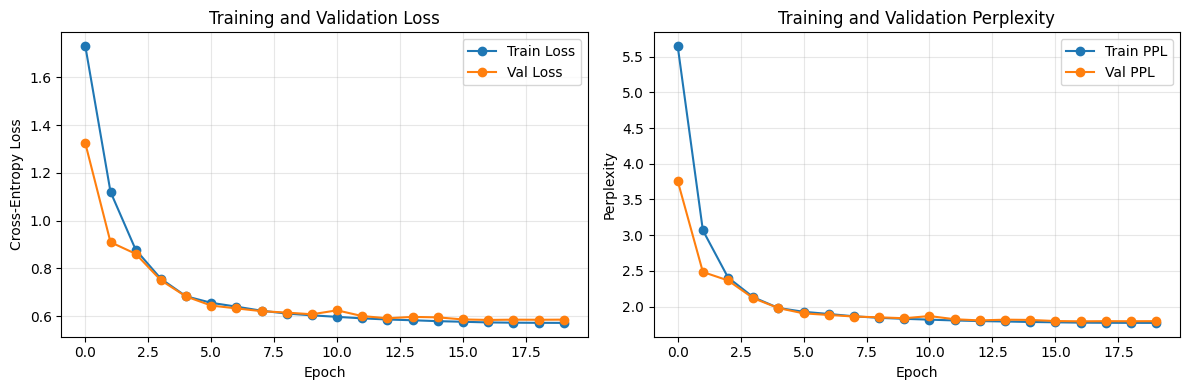

In [43]:
# ============================================================================
# TRAINING VISUALIZATION
# ============================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Perplexity plot
axes[1].plot(history['train_ppl'], label='Train PPL', marker='o')
axes[1].plot(history['val_ppl'], label='Val PPL', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Training and Validation Perplexity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
# ============================================================================
# GENERATE PATIENT TIMELINE
# ============================================================================

# Load best model
model.load_state_dict(torch.load('best_medical_gpt.pt', weights_only=True))
model.eval()

def generate_timeline(prompt_tokens, max_tokens=100, temperature=0.8, top_k=50):
    """Generate a patient timeline starting from a prompt."""
    # Convert prompt tokens to indices
    prompt_indices = [token_to_idx.get(t, token_to_idx['<UNK>']) for t in prompt_tokens]
    input_ids = torch.tensor([prompt_indices], dtype=torch.long, device=device)
    
    # Generate
    output_ids = model.generate(input_ids, max_new_tokens=max_tokens, temperature=temperature, top_k=top_k)
    
    # Convert back to tokens
    generated_tokens = [idx_to_token[idx.item()] for idx in output_ids[0]]
    
    return generated_tokens

# Example: Start with demography and generate rest of timeline
prompt = ['<BOS>', 'SEX_M', 'MARITAL_MARRIED', 'RACE_WHITE']
print("=" * 80)
print("GENERATING PATIENT TIMELINE")
print("=" * 80)
print(f"\nPrompt: {' '.join(prompt)}")
print("\nGenerated sequence:")
print("-" * 80)

generated = generate_timeline(prompt, max_tokens=100, temperature=0.8, top_k=50)
print(' '.join(generated))

print("\n" + "-" * 80)
print(f"Total tokens generated: {len(generated) - len(prompt)}")

GENERATING PATIENT TIMELINE

Prompt: <BOS> SEX_M MARITAL_MARRIED RACE_WHITE

Generated sequence:
--------------------------------------------------------------------------------
<BOS> SEX_M MARITAL_MARRIED RACE_WHITE <ICD_PCS_8> <ICD_PCS_A> <ICD_PCS_9> <ICD_PCS_0> <ICD_PCS_1> <ICD_PCS_5> <ICD_PCS_9> <ICD_PCS_Z> <ICD_PCS_4> <ICD_PCS_0> <ICD_PCS_3> <ICD_PCS_Z> <ICD_PCS_0> <ICD_PCS_6> <ICD_PCS_E> <ICD_PCS_2> <ICD_PCS_6> <ICD_PCS_4> <ICD_PCS_2> <ICD_PCS_3> <TIME_2h-6h> <ICD_F_414> <ICD_3_5_21> <ICD_F_518> <ICD_3_5_8> <ICD_6_XA> <ICD_F_R57> <ICD_3_5_5> <ICD_F_E11> <ICD_3_5_9> <ICD_F_276> <ICD_3_5_3> <ICD_F_E87> <ICD_3_5_0> <ICD_F_E87> <ICD_3_5_8> <ICD_F_V45> <ICD_3_5_0> <ICD_6_0> <ICD_F_E87> <ICD_3_5_0> <ICD_F_285> <ICD_3_5_9> <ICD_F_276> <ICD_3_5_81> <ICD_F_V12> <ICD_3_5_97> <ICD_F_V15> <ICD_3_5_2> <ICD_F_E87> <ICD_3_5_2> <ICD_F_Y92> <ICD_3_5_9> <ICD_F_R74> <ICD_3_5_9> <ICD_F_Z87> <ICD_3_5_1> <ICD_F_E84> <ICD_3_5_2> <ICD_F_V15> <ICD_3_5_00> <ICD_F_Z51> <ICD_3_5_0> <ICD_F_Z79> <ICD_3_5_81> 

In [45]:
# ============================================================================
# MULTIPLE GENERATION EXAMPLES
# ============================================================================

# Try different prompts
prompts = [
    # Start with female patient
    ['<BOS>', 'SEX_F', 'MARITAL_SINGLE', 'RACE_BLACK_AFRICAN_AMERICAN'],
    # Start with some diagnoses
    ['<BOS>', 'SEX_M', '<ICD_F_I10>', '<ICD_F_E11>'],  # Hypertension + Diabetes
    # Start with lab results
    ['<BOS>', 'SEX_F', '<LAB', 'Hemoglobin>', '<Q3>'],
]

for i, prompt in enumerate(prompts, 1):
    print(f"\n{'='*80}")
    print(f"GENERATION {i}")
    print(f"{'='*80}")
    print(f"Prompt: {' '.join(prompt)}")
    print("-" * 40)
    
    generated = generate_timeline(prompt, max_tokens=80, temperature=0.9, top_k=40)
    
    # Format output nicely
    output = ' '.join(generated[len(prompt):])
    # Wrap at 80 chars
    words = output.split()
    lines = []
    current_line = []
    current_len = 0
    for word in words:
        if current_len + len(word) + 1 > 80:
            lines.append(' '.join(current_line))
            current_line = [word]
            current_len = len(word)
        else:
            current_line.append(word)
            current_len += len(word) + 1
    if current_line:
        lines.append(' '.join(current_line))
    
    print('\n'.join(lines))


GENERATION 1
Prompt: <BOS> SEX_F MARITAL_SINGLE RACE_BLACK_AFRICAN_AMERICAN
----------------------------------------
<ICD_PCS_3> <ICD_PCS_1> <ICD_PCS_9> <ICD_PCS_9> <ICD_PCS_6> <TIME_2h-6h>
<ICD_F_577> <ICD_3_5_9> <ICD_F_507> <ICD_3_5_1> <ICD_F_E87> <ICD_3_5_4>
<ICD_F_401> <ICD_3_5_9> <ICD_F_E11> <ICD_3_5_3> <TIME_2h-6h> <UNK> <UNK> <UNK>
<UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>
<UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>
<UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>
<UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>
<UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>

GENERATION 2
Prompt: <BOS> SEX_M <ICD_F_I10> <ICD_F_E11>
----------------------------------------
<ICD_3_5_8> <ICD_F_599> <ICD_3_5_5> <ICD_F_C91> <ICD_3_5_84> <ICD_6_9>
<ICD_F_I50> <ICD_3_5_01> <ICD_F_276> <ICD_3_5_0> <ICD_F_276> <ICD_3_5_02>
<ICD_F_403> <ICD_3_5_30> <ICD_F_V58> <ICD_3_5_9> <ICD_

In [46]:
# ============================================================================
# MODEL SUMMARY
# ============================================================================

print("=" * 60)
print("MEDICAL GPT MODEL SUMMARY")
print("=" * 60)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"""
Architecture:
  - Model type:           Autoregressive Transformer (GPT-style)
  - Vocabulary size:      {VOCAB_SIZE:,}
  - Embedding dimension:  256
  - Attention heads:      4
  - Transformer layers:   4
  - Feed-forward dim:     512
  - Max sequence length:  {SEQ_LENGTH}
  - Dropout:              0.1

Training:
  - Training samples:     {len(train_dataset):,}
  - Validation samples:   {len(val_dataset):,}
  - Batch size:           {BATCH_SIZE}
  - Learning rate:        {LEARNING_RATE}
  - Epochs:               {NUM_EPOCHS}
  - Best val loss:        {best_val_loss:.4f}
  - Best val perplexity:  {math.exp(best_val_loss):.2f}

Parameters:
  - Total:                {n_params:,} ({n_params/1e6:.2f}M)
  - Trainable:            {n_trainable:,}

Device: {device}
""")

print("Model can generate patient health timelines including:")
print("  - Demographics (sex, race, marital status)")
print("  - Diagnoses (ICD codes)")
print("  - Procedures (ICD-PCS codes)")
print("  - Medications (ATC codes)")
print("  - Lab results (with quantile values)")
print("  - Time intervals between events")

MEDICAL GPT MODEL SUMMARY

Architecture:
  - Model type:           Autoregressive Transformer (GPT-style)
  - Vocabulary size:      2,269
  - Embedding dimension:  256
  - Attention heads:      4
  - Transformer layers:   4
  - Feed-forward dim:     512
  - Max sequence length:  256
  - Dropout:              0.1

Training:
  - Training samples:     2,388
  - Validation samples:   266
  - Batch size:           16
  - Learning rate:        0.0003
  - Epochs:               20
  - Best val loss:        0.5838
  - Best val perplexity:  1.79

Parameters:
  - Total:                2,689,792 (2.69M)
  - Trainable:            2,689,792

Device: mps

Model can generate patient health timelines including:
  - Demographics (sex, race, marital status)
  - Diagnoses (ICD codes)
  - Procedures (ICD-PCS codes)
  - Medications (ATC codes)
  - Lab results (with quantile values)
  - Time intervals between events
